# ``joblib`` Practice Problem: Producing density maps in Parallel

- We will analyse a 2D turbulence-in-a-box simulation in parallel.

- The VTK files can be fetched from:

https://www.dropbox.com/scl/fo/aip4lo4983phsyd5tcn77/ALvNSCjfQpzlbjrKmhP5Ex8?rlkey=m4ragdal7lagwczhtkvyqj0ty&dl=0

- Task: Use the VTK database and make density maps in parallel using joblib.


## Serial code:

```python
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import time
from joblib import Parallel, delayed

# I/O function
def io_turbulence(fname):
    """

    """
    # Split the name to get the numbers only
    n_fname = os.path.basename(fname).split(".")[1]

    # Get the data into a mesh
    mesh = pv.read(fname)

    # Get data arrays in code units
    rho = pv.get_array(mesh, "rho", preference = 'cell')

    # Reshape the density array into a 2D array
    rho_2d = rho.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)

    # Add the mesh
    # Create coordinate vectors:
    x = np.linspace(mesh.bounds[0], mesh.bounds[1], mesh.dimensions[1] - 1)
    y = np.linspace(mesh.bounds[2], mesh.bounds[3], mesh.dimensions[0] - 1)

    # Generate Grid
    x_2d, y_2d = np.meshgrid(x, y)

    # Plotting the density
    plt.figure(figsize=(4,3))

    z_dens = plt.pcolor(x_2d, y_2d, np.log10(rho_2d), cmap = "Blues")#, vmin = -25, vmax=-23)

    plt.colorbar(z_dens)

    plt.savefig(f"./img_turb/dens_{n_fname}.jpg")

    plt.close()

# Execution line
if __name__ == "__main__":

    # For testing
    #FILE_NAME = "data.0000.vtk"

    # Function Call 
    #io_turbulence("./TURB_DRIVE_SUP_hr/" + FILE_NAME)

    # Start time stamp
    #start = time.time()

    # Number of cores
    n_cores = 2

    # File name -> File list
    b_path = "./TURB_DRIVE_SUP_hr/"

    # Adapt filenames
    file_list = [os.path.join(b_path + f"data.0{j:03d}.vtk") for j in range(100)]
    #print(file_list)
    
    # Start time stamp
    start = time.time()

    # Perform the parallelisation
    results = Parallel(n_jobs = n_cores, batch_size = 100//n_cores)(delayed(io_turbulence)(i) for i in file_list)

    # Start time stamp
    end = time.time()

    # Print the execution time
    print("The parallel execution time in seconds is: ", np.round(end - start, 4))
```

#### Reference: https://github.com/wbandabarragan/computational-physics-2/blob/main/unit-3/turbulence_joblib.py


## Parallel code:

```python
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import time
from joblib import Parallel, delayed
import pandas as pd

# I/O function
def io_turbulence(fname):
    """

    """
    # Split the name to get the numbers only
    n_fname = os.path.basename(fname).split(".")[1]

    # Get the data into a mesh
    mesh = pv.read(fname)

    # Get data arrays in code units
    rho = pv.get_array(mesh, "rho", preference = 'cell')

    # Reshape the density array into a 2D array
    rho_2d = rho.reshape(mesh.dimensions[0] - 1, mesh.dimensions[1] - 1)

    # Add the mesh
    # Create coordinate vectors:
    x = np.linspace(mesh.bounds[0], mesh.bounds[1], mesh.dimensions[1] - 1)
    y = np.linspace(mesh.bounds[2], mesh.bounds[3], mesh.dimensions[0] - 1)

    # Generate Grid
    x_2d, y_2d = np.meshgrid(x, y)

    # Plotting the density
    plt.figure(figsize=(4,3))

    z_dens = plt.pcolor(x_2d, y_2d, np.log10(rho_2d), cmap = "Blues")#, vmin = -25, vmax=-23)

    plt.colorbar(z_dens)

    plt.savefig(f"./img_turb/dens_{n_fname}.jpg")

    plt.close()

# Execution line
if __name__ == "__main__":

    # For testing
    #FILE_NAME = "data.0000.vtk"

    # Function Call 
    #io_turbulence("./TURB_DRIVE_SUP_hr/" + FILE_NAME)

    # Start time stamp
    #start = time.time()

    # Number of cores
    n_list = [1, 2, 4, 5, 10]
    e_list = []

    # File name -> File list
    b_path = "./TURB_DRIVE_SUP_hr/"

    for k in n_list:
        #print(k)
        # Adapt filenames
        file_list = [os.path.join(b_path + f"data.0{j:03d}.vtk") for j in range(100)]
        #print(file_list)
    
        # Start time stamp
        start = time.time()

        # Perform the parallelisation
        results = Parallel(n_jobs = k, batch_size = 100//k, backend = "multiprocessing")(delayed(io_turbulence)(i) for i in file_list)

        # Start time stamp
        end = time.time()
        
        exec_time = np.round(end - start, 4)

        e_list.append(exec_time)
        
        # Print the execution time
        print("The parallel execution time in seconds is: ", exec_time)

    #print(e_list)
    # Switch to arrays -> dataframes


    # Writing a new data frame

    df = pd.DataFrame({"n_cores": np.array(n_list), "e_times": np.array(e_list)})

    # Output a new post-processed file
    df.to_csv("./scaling.csv", ",", float_format = "{:.2e}".format, index = None)

```

#### Reference: https://github.com/wbandabarragan/computational-physics-2/blob/main/unit-3/turbulence_joblib_v2.py

## Results:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Start our I/O function 

def io_scaling(filename):
    
    """

    """
    
    # Create a pandas DF:
    data_wc = pd.read_csv(filename, sep = ",")
    
    # Get the data from each column into arrays:
    n = np.array(data_wc["n_cores"])
    e = np.array(data_wc["e_times"])
    
    return n, e

In [3]:
# Call our function

n_arr, e_arr = io_scaling("./scaling.csv")


In [4]:
print(n_arr)
print(e_arr)
i_arr = np.full(n_arr.shape, e_arr[0])/n_arr
print(i_arr)

[ 1  2  4  5 10]
[17.7   9.91  5.76  4.79  3.33]
[17.7    8.85   4.425  3.54   1.77 ]


### Linear-scale plot:

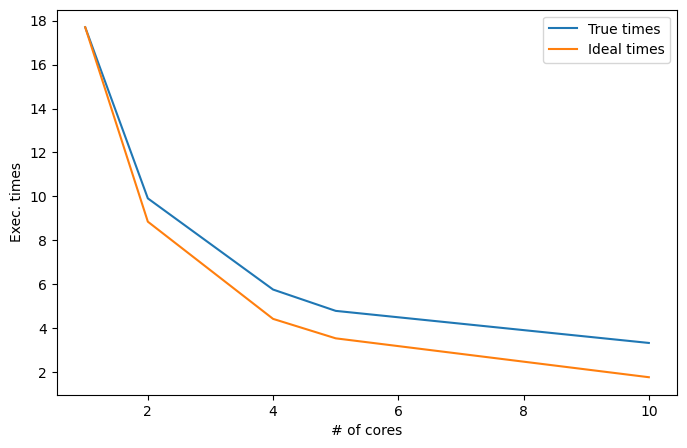

In [5]:
plt.figure(figsize = (8, 5))

plt.plot(n_arr, e_arr, label = "True times")

plt.plot(n_arr, i_arr, label = "Ideal times")

plt.xlabel("# of cores")
plt.ylabel("Exec. times")

plt.legend()

plt.show()

### $\log_2$-scale plot:

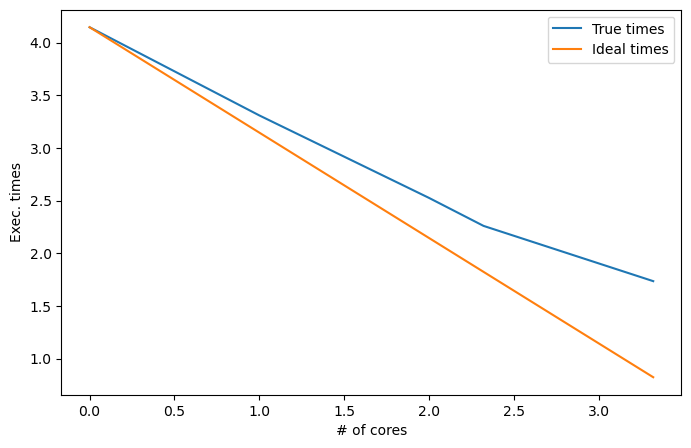

In [6]:
plt.figure(figsize = (8, 5))

plt.plot(np.log2(n_arr), np.log2(e_arr), label = "True times")

plt.plot(np.log2(n_arr), np.log2(i_arr), label = "Ideal times")

plt.xlabel("# of cores")
plt.ylabel("Exec. times")

plt.legend()

plt.show()